# PRODIGY_DS_01 — Distribution Visualization (Bar Chart & Histogram)
**Prodigy InfoTech — Data Science Internship, Task 01**

Task: Create a bar chart or histogram to visualize the distribution of a categorical or continuous variable, such as the distribution of ages or genders in a population.

**Dataset:** the official sample dataset provided for this task — World Bank population data (2001-2022) for 217 countries, with total/male/female population series.

## 1. Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 2. Load the dataset
Downloads the provided dataset directly, so this notebook runs standalone in Colab with no manual upload needed.

In [2]:
!wget -q -O world_population.csv https://raw.githubusercontent.com/ashrafeesa/PRODIGY_DS_01/main/worldpopulationdata.csv
raw = pd.read_csv("world_population.csv")
print(raw.shape)
raw.head()

(1085, 26)


,Series Name,Series Code,Country Name,Country Code,2022,2021,2020,2019,2018,2017,...,2010,2009,2008,2007,2006,2005,2004,2003,2002,2001
0,"Population, total",SP.POP.TOTL,Afghanistan,AFG,41128771.0,40099462.0,38972230.0,37769499.0,36686784.0,35643418.0,...,28189672.0,27385307.0,26427199.0,25903301.0,25442944.0,24411191.0,23553551.0,22645130.0,21000256.0,19688632.0
1,"Population, total",SP.POP.TOTL,Albania,ALB,2775634.0,2811666.0,2837849.0,2854191.0,2866376.0,2873457.0,...,2913021.0,2927519.0,2947314.0,2970017.0,2992547.0,3011487.0,3026939.0,3039616.0,3051010.0,3060173.0
2,"Population, total",SP.POP.TOTL,Algeria,DZA,44903225.0,44177969.0,43451666.0,42705368.0,41927007.0,41136546.0,...,35856344.0,35196037.0,34569592.0,33983827.0,33435080.0,32956690.0,32510186.0,32055883.0,31624696.0,31200985.0
3,"Population, total",SP.POP.TOTL,American Samoa,ASM,44273.0,45035.0,46189.0,47321.0,48424.0,49463.0,...,54849.0,55366.0,55891.0,56383.0,56837.0,57254.0,57626.0,57941.0,58177.0,58324.0
4,"Population, total",SP.POP.TOTL,Andorra,AND,79824.0,79034.0,77700.0,76343.0,75013.0,73837.0,...,71519.0,73852.0,76055.0,78168.0,80221.0,79826.0,76933.0,73907.0,70849.0,67820.0


## 3. Inspect and clean the data
The file stacks **5 series per country** (total/male/female population, and male/female % of total) in the `Series Name` column. We must filter to one series at a time before analyzing, or counts get mixed together.

In [3]:
print("Series Name values:", raw["Series Name"].unique().tolist())
print("Missing values total:", raw.isnull().sum().sum())

total_pop = raw[raw["Series Name"] == "Population, total"][["Country Name", "2022"]]
total_pop = total_pop.rename(columns={"2022": "Population_2022"}).dropna()
print("\nAfter filtering:", total_pop.shape)
total_pop.head()

Series Name values: ['Population, total', 'Population, female', 'Population, male', 'Population, female (% of total population)', 'Population, male (% of total population)']
Missing values total: 0

After filtering: (217, 2)


,Country Name,Population_2022
0,Afghanistan,41128771.0
1,Albania,2775634.0
2,Algeria,44903225.0
3,American Samoa,44273.0
4,Andorra,79824.0


## 4. Bar chart — Top 15 most populous countries (categorical: Country)
A bar chart shows a value for each distinct category — here, each country gets its own bar, making it easy to compare a ranked list.

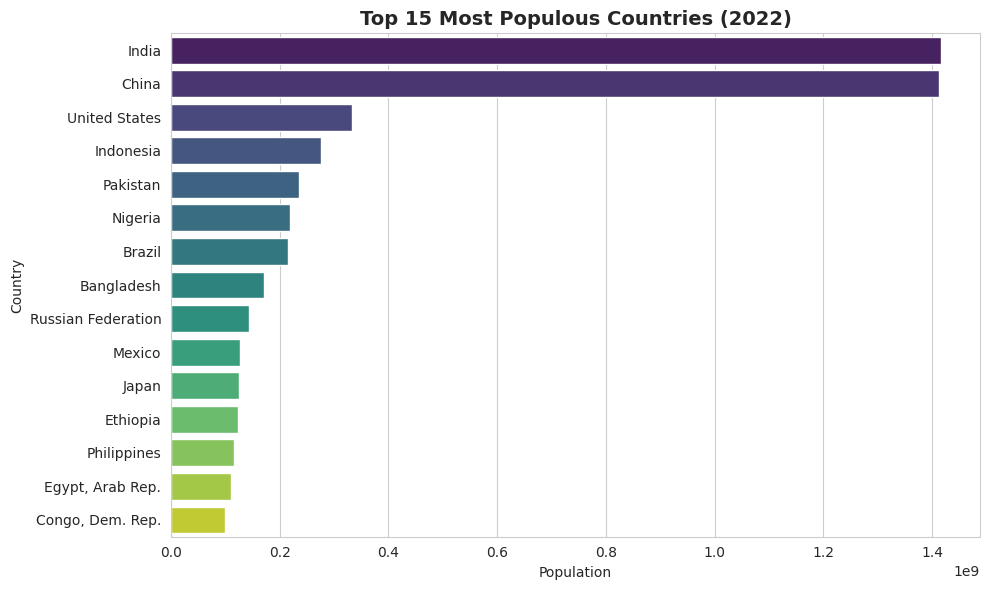

In [4]:
top15 = total_pop.sort_values("Population_2022", ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top15, x="Population_2022", y="Country Name", hue="Country Name", palette="viridis", legend=False)
plt.title("Top 15 Most Populous Countries (2022)", fontsize=14, fontweight="bold")
plt.xlabel("Population")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("top15_population_bar_chart.png", dpi=150)
plt.show()

## 5. Histogram — Distribution of population across all countries (continuous)
A histogram bins continuous values into ranges to reveal the *shape* of the distribution. A log scale is used on the x-axis since population values span several orders of magnitude (thousands to over a billion).

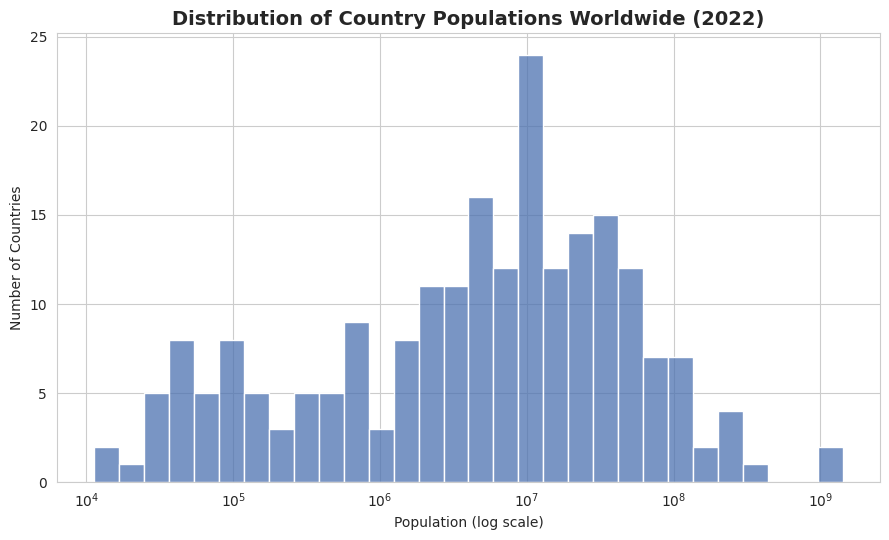

In [5]:
plt.figure(figsize=(9, 5.5))
sns.histplot(total_pop["Population_2022"], bins=30, color="#4C72B0", log_scale=(True, False))
plt.title("Distribution of Country Populations Worldwide (2022)", fontsize=14, fontweight="bold")
plt.xlabel("Population (log scale)")
plt.ylabel("Number of Countries")
plt.tight_layout()
plt.savefig("population_distribution_histogram.png", dpi=150)
plt.show()

## 6. Bonus — World population by gender (categorical)
Using the male/female series already present in the dataset.

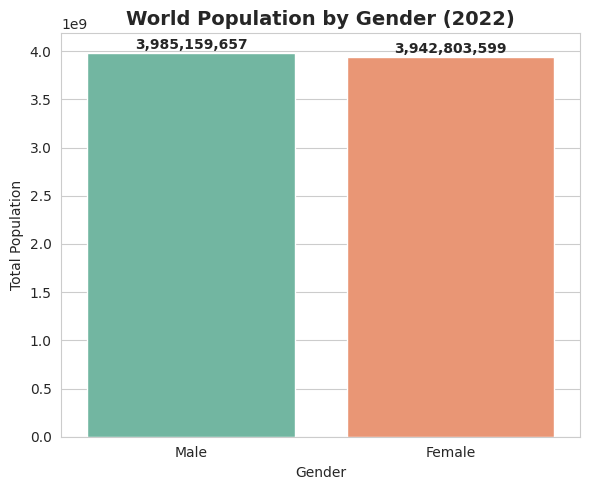

In [6]:
male_pop = raw[raw["Series Name"] == "Population, male"]["2022"].sum()
female_pop = raw[raw["Series Name"] == "Population, female"]["2022"].sum()

gender_df = pd.DataFrame({"Gender": ["Male", "Female"], "Population": [male_pop, female_pop]})

plt.figure(figsize=(6, 5))
sns.barplot(data=gender_df, x="Gender", y="Population", hue="Gender", palette="Set2", legend=False)
plt.title("World Population by Gender (2022)", fontsize=14, fontweight="bold")
plt.ylabel("Total Population")
for i, v in enumerate(gender_df["Population"]):
    plt.text(i, v + v * 0.01, f"{v:,.0f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("gender_distribution_bar_chart.png", dpi=150)
plt.show()

## 7. Key Insights
- **India (1.417B)** narrowly overtook **China (1.412B)** as the world's most populous country by 2022.
- The population distribution across all 217 countries is **heavily right-skewed** — most countries have modest populations, while a handful account for a disproportionate share of the world's people.
- The global gender split is close to even: **~3.99B male vs. ~3.94B female** in 2022.

---
*Part of the Data Science Internship @ Prodigy InfoTech (Oct 2026)* #ProdigyInfoTech